# Traditional ML Baseline: SVM & Random Forest for Lung CT

This notebook serves as a standalone baseline to compare against Deep Learning methods. It implements:
1.  **SVM (Support Vector Machine):** Uses PCA for dimensionality reduction.
2.  **Random Forest:** Operates on raw pixel data to determine feature importance.

**Visualizations:**
- SVM Decision Boundary (in 2D PCA space).
- Random Forest Pixel Importance Heatmap (interpretable visualization).
- Confusion Matrices.

**Assumptions:**
- Data located in `./Dataset/` (same structure as DL notebook).

In [1]:
# --- Imports ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Config
DATA_DIR = './Dataset'
IMG_SIZE = (64, 64) # Resize to 64x64 to keep feature count manageable (4096 features)
SEED = 42

np.random.seed(SEED)

In [2]:
# --- 1. Load and Preprocess Data ---
class_names = ['Benign', 'Normal', 'Adenocarcinoma', 'Large_cell_carcinoma', 'Squamous_Cell_Carcinoma']

def load_data(data_dir, img_size):
    print("Scanning dataset...")
    X = []
    y = []
    files_found = 0
    
    for cls in class_names:
        cls_folder = os.path.join(data_dir, cls)
        if not os.path.exists(cls_folder):
            print(f"Warning: Folder not found {cls_folder}")
            continue
            
        # Label: 0 for Normal, 1 for Disease (Binary Classification)
        label = 0 if cls == 'Normal' else 1
        
        for img_path in Path(cls_folder).glob('*'):
            if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tif']:
                try:
                    # Open, Convert to Grayscale (L), Resize
                    img = Image.open(img_path).convert('L').resize(img_size)
                    # Flatten: 2D image -> 1D vector (64*64 = 4096 features)
                    img_flat = np.array(img).flatten()
                    X.append(img_flat)
                    y.append(label)
                    files_found += 1
                except Exception as e:
                    pass
                    
    print(f"Loaded {files_found} images. Shape: {np.array(X).shape}")
    return np.array(X), np.array(y)

X, y = load_data(DATA_DIR, IMG_SIZE)

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")

Scanning dataset...
Loaded 1535 images. Shape: (1535, 4096)
Train shape: (1228, 4096) | Test shape: (307, 4096)


In [3]:
# --- 2. Train SVM (with PCA) ---
print("\n--- Training SVM ---")
print("Preprocessing: Scaler -> PCA (0.95 variance) -> SVC")

# SVM Pipeline: Scale features -> Reduce dims (PCA) -> Classifier
# We use PCA because 4096 features is often too noisy/slow for SVM RBF kernel
svm_pipe = make_pipeline(
    StandardScaler(),
    PCA(n_components=0.95, random_state=SEED), # Keep 95% of variance
    SVC(kernel='rbf', C=1.0, probability=True, random_state=SEED)
)

t0 = time.time()
svm_pipe.fit(X_train, y_train)
print(f"SVM Training Time: {time.time()-t0:.2f}s")

y_pred_svm = svm_pipe.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {acc_svm:.4f}")


--- Training SVM ---
Preprocessing: Scaler -> PCA (0.95 variance) -> SVC
SVM Training Time: 2.06s
SVM Accuracy: 0.9544


In [4]:
# --- 3. Train Random Forest (Raw Pixels) ---
print("\n--- Training Random Forest ---")
print("Preprocessing: Raw Pixels -> Random Forest (100 Trees)")

# RF handles raw high-dim features well and gives us feature importance
rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)

t0 = time.time()
rf_model.fit(X_train, y_train)
print(f"RF Training Time: {time.time()-t0:.2f}s")

y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"RF Accuracy: {acc_rf:.4f}")


--- Training Random Forest ---
Preprocessing: Raw Pixels -> Random Forest (100 Trees)
RF Training Time: 0.47s
RF Accuracy: 0.9805


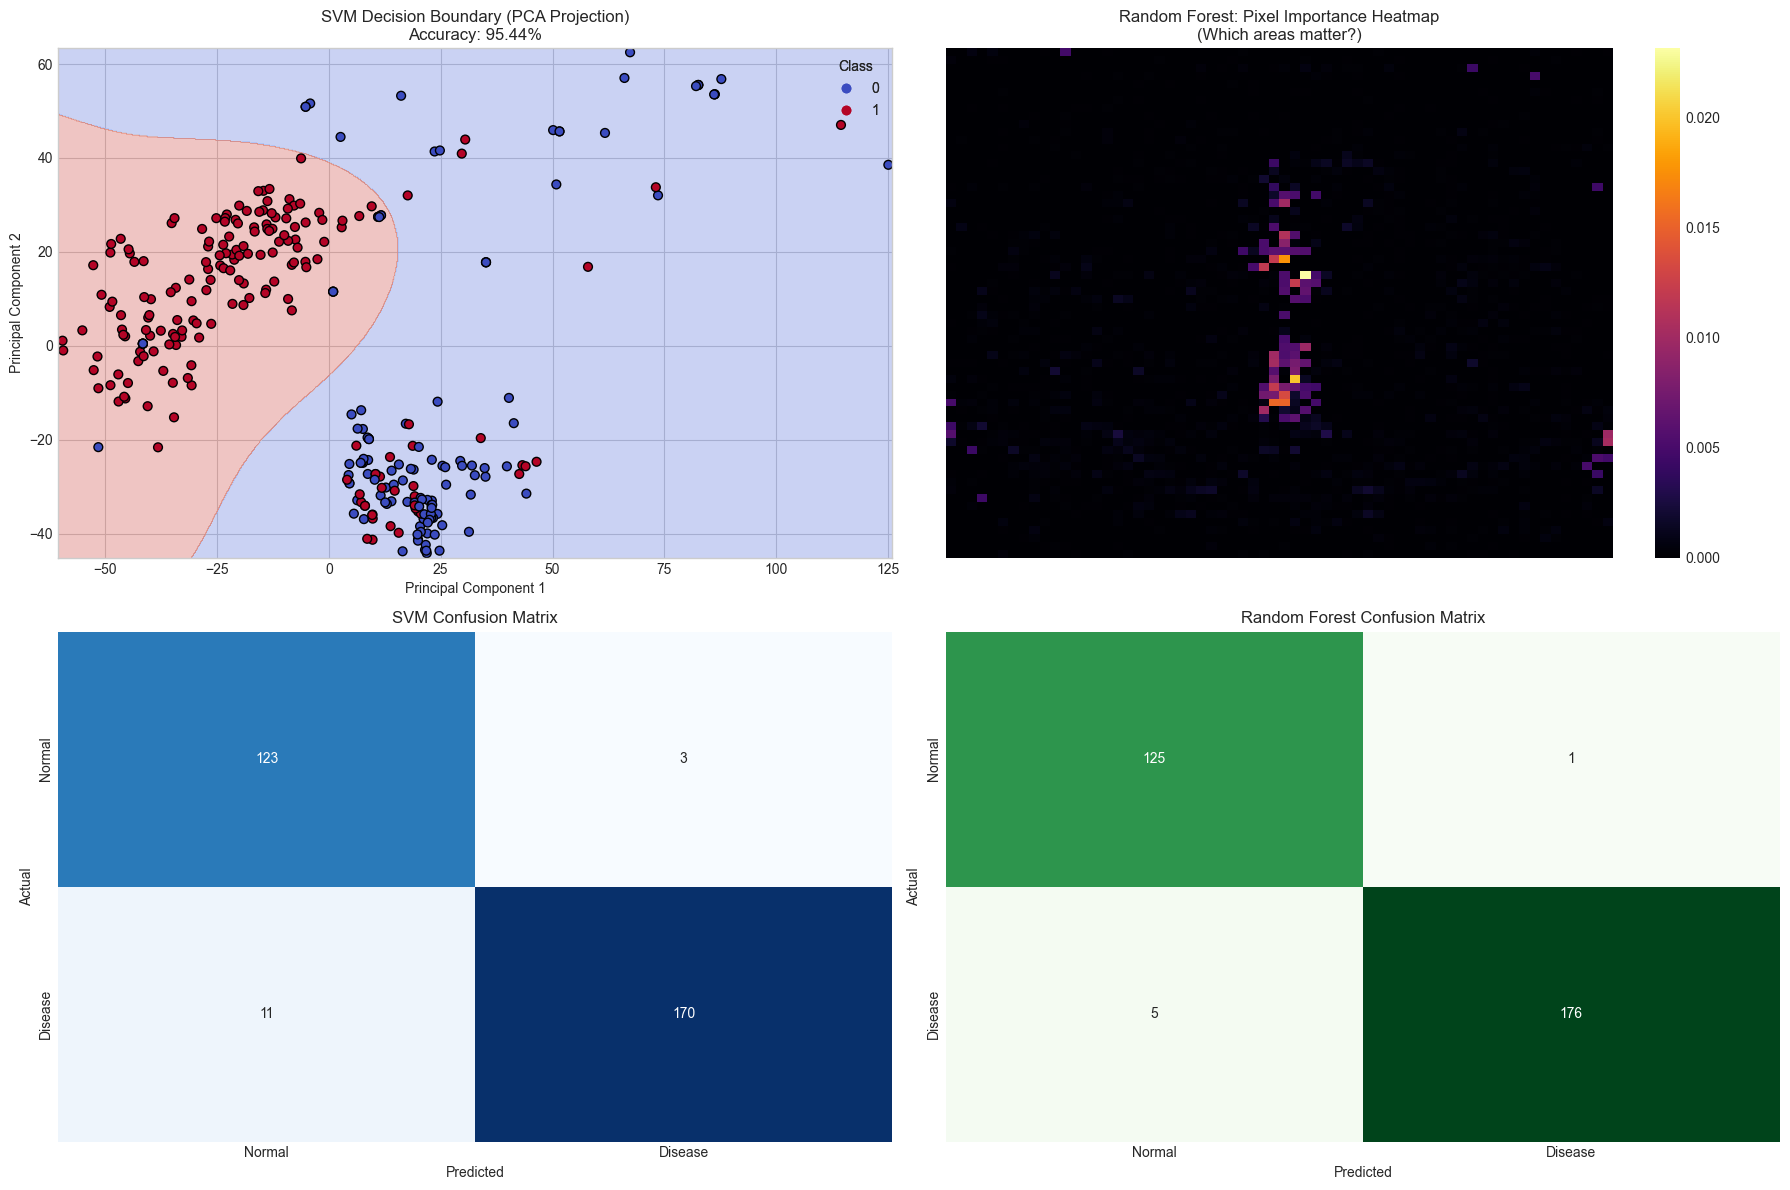

In [5]:
# --- 4. Visualizations ---
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(18, 12))

# --- Viz 1: SVM Decision Boundary (PCA Projection) ---
# To visualize the boundary, we need to train a 2D SVM just for the plot
ax1 = plt.subplot(2, 2, 1)

# 1. Get PCA transformation of data
pca_2d = PCA(n_components=2)
X_train_pca2 = pca_2d.fit_transform(StandardScaler().fit_transform(X_train))
X_test_pca2 = pca_2d.transform(StandardScaler().fit_transform(X_test))

# 2. Train simple SVM on 2D data for visualization
svm_2d = SVC(kernel='rbf', C=1.0)
svm_2d.fit(X_train_pca2, y_train)

# 3. Create meshgrid
x_min, x_max = X_test_pca2[:, 0].min() - 1, X_test_pca2[:, 0].max() + 1
y_min, y_max = X_test_pca2[:, 1].min() - 1, X_test_pca2[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.2), np.arange(y_min, y_max, 0.2))
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 4. Plot
ax1.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
scatter = ax1.scatter(X_test_pca2[:, 0], X_test_pca2[:, 1], c=y_test, s=40, edgecolors='k', cmap=plt.cm.coolwarm)
ax1.set_title(f'SVM Decision Boundary (PCA Projection)\nAccuracy: {acc_svm:.2%}')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
legend1 = ax1.legend(*scatter.legend_elements(), title="Class")
ax1.add_artist(legend1)


# --- Viz 2: Random Forest Pixel Importance ---
# Reshape importances (4096,) back to image (64, 64)
ax2 = plt.subplot(2, 2, 2)
importances = rf_model.feature_importances_.reshape(IMG_SIZE)
sns.heatmap(importances, cmap='inferno', ax=ax2)
ax2.set_title('Random Forest: Pixel Importance Heatmap\n(Which areas matter?)')
ax2.axis('off')


# --- Viz 3: Confusion Matrices ---
ax3 = plt.subplot(2, 2, 3)
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar=False)
ax3.set_title('SVM Confusion Matrix')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')
ax3.set_xticklabels(['Normal', 'Disease'])
ax3.set_yticklabels(['Normal', 'Disease'])

ax4 = plt.subplot(2, 2, 4)
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=ax4, cbar=False)
ax4.set_title('Random Forest Confusion Matrix')
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')
ax4.set_xticklabels(['Normal', 'Disease'])
ax4.set_yticklabels(['Normal', 'Disease'])

plt.tight_layout()
plt.show()

In [6]:
# --- Final Classification Reports ---
print("SVM Report:")
print(classification_report(y_test, y_pred_svm, target_names=['Normal', 'Disease']))

print("\nRandom Forest Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Disease']))

SVM Report:
              precision    recall  f1-score   support

      Normal       0.92      0.98      0.95       126
     Disease       0.98      0.94      0.96       181

    accuracy                           0.95       307
   macro avg       0.95      0.96      0.95       307
weighted avg       0.96      0.95      0.95       307


Random Forest Report:
              precision    recall  f1-score   support

      Normal       0.96      0.99      0.98       126
     Disease       0.99      0.97      0.98       181

    accuracy                           0.98       307
   macro avg       0.98      0.98      0.98       307
weighted avg       0.98      0.98      0.98       307

